In [1]:
import pandas as pd
import numpy as np
from scipy import stats
oil_data = pd.read_excel(r"C:/Users/safiy/Downloads/Desktop/Paper Presentation/USA/DATASET 1.xlsx")
oil_data['MONTH'] = pd.to_datetime(oil_data['MONTH'])
oil_data = oil_data.set_index('MONTH')
oil_data = oil_data.sort_index()
oil_data

,OIL PRICE (USD),INDIA_CPI,INDIA_EXCHANGE_RATE,GERMANY_CPI,GERMANY_EXCHANGE_RATE,CHINA_CPI,CHINA_EXCHANGE_RATE,SOUTH_KOREA_CPI,SOUTH_KOREA_EXCHANGE _RATE,USA_EXCHANGE RATE,USA_CPI
MONTH,,,,,,,,,,,
2006-01-01,58.76,45.52120,44.2010,86.85491,1.211782,76.64962,7.8622,79.306634,981.44,100.0000,199.300
2006-02-01,62.47,45.52120,44.2300,87.22808,1.193944,77.03287,7.8219,79.464760,969.84,100.2112,199.400
2006-03-01,53.68,45.52120,44.3378,87.22808,1.203098,76.33958,7.7876,79.934922,974.71,100.4281,199.700
2006-04-01,57.56,45.90373,44.8245,87.50796,1.228206,76.49226,7.7502,80.013985,952.60,99.7435,200.700
2006-05-01,62.05,46.28626,45.1959,87.50796,1.277293,76.41576,7.7369,80.170003,940.82,97.5118,201.300
...,...,...,...,...,...,...,...,...,...,...,...
2022-08-01,74.84,143.44920,79.5065,116.70920,1.013096,115.00400,7.1614,114.504481,1319.41,122.3262,295.162
2022-09-01,80.11,144.66110,80.2538,118.81780,0.989678,115.33870,7.1863,114.831275,1396.37,125.5999,296.421
2022-10-01,86.15,145.98320,82.2915,119.66120,0.983990,115.45020,7.2486,115.126444,1426.07,127.4828,297.979


## === STATISTICAL ANALYSIS ===

In [2]:
# Missing value check
oil_data.isna().sum()


OIL PRICE (USD)               0
INDIA_CPI                     0
INDIA_EXCHANGE_RATE           0
GERMANY_CPI                   0
GERMANY_EXCHANGE_RATE         0
CHINA_CPI                     0
CHINA_EXCHANGE_RATE           0
SOUTH_KOREA_CPI               0
SOUTH_KOREA_EXCHANGE _RATE    0
USA_EXCHANGE RATE             0
USA_CPI                       0
dtype: int64

In [3]:
oil_data = oil_data.fillna(method='ffill')   # forward fill


C:\Users\safiy\AppData\Local\Temp\ipykernel_27504\45655477.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  oil_data = oil_data.fillna(method='ffill')   # forward fill


## Plot raw time series

<Axes: xlabel='MONTH'>

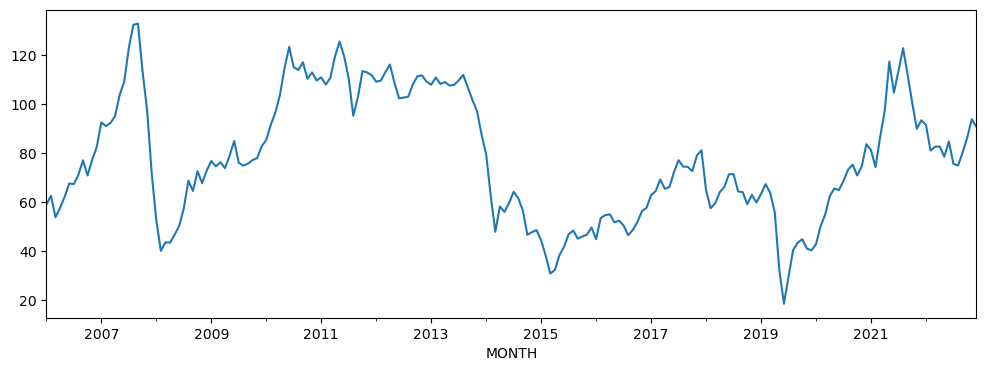

In [4]:
oil_data['OIL PRICE (USD)'].plot(figsize=(12,4))


## Summary Statistics

In [5]:
import pandas as pd

# Descriptive statistics
desc =oil_data.describe().T

# Add skewness
desc['skewness'] = oil_data.skew()

# Add kurtosis
desc['kurtosis'] = oil_data.kurt()

desc


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
OIL PRICE (USD),204.0,77.577990,25.349200,18.380000,57.547500,74.475000,102.327500,132.720000,0.155785,-0.964898
INDIA_CPI,204.0,92.170465,29.642643,45.521200,65.604083,95.250240,115.141900,145.983200,0.027518,-1.177498
INDIA_EXCHANGE_RATE,204.0,59.121067,12.120482,39.267600,46.488850,61.900750,69.392700,82.473800,-0.045587,-1.338644
GERMANY_CPI,204.0,99.233309,7.210827,86.854910,93.198770,99.336300,104.217400,119.872100,0.511524,0.139520
GERMANY_EXCHANGE_RATE,204.0,1.245631,0.131419,0.983990,1.129626,1.233559,1.342348,1.575774,0.307668,-0.673350
CHINA_CPI,204.0,97.265689,11.444952,75.805580,86.295032,98.600000,106.500000,115.450200,-0.192072,-1.064634
CHINA_EXCHANGE_RATE,204.0,6.688523,0.399815,6.050900,6.362300,6.697100,6.887600,7.862200,0.712541,0.351109
SOUTH_KOREA_CPI,204.0,97.476941,9.059080,79.306634,90.611342,99.313293,104.385719,115.200236,-0.348603,-0.644667
SOUTH_KOREA_EXCHANGE _RATE,204.0,1123.239951,104.096926,914.940000,1074.887500,1125.760000,1174.020000,1449.620000,0.294206,0.952027
USA_EXCHANGE RATE,204.0,103.251275,11.155101,86.317800,93.191900,100.390100,113.892125,127.482800,0.164947,-1.417105


### Correlation

In [6]:
# === CORRELATION ANALYSIS ===

# Step 2 — Standardize the dataset
oil_data_standardized = (oil_data - oil_data.mean()) / oil_data.std()

# Step 3 — Compute correlation matrix
corr_matrix = oil_data_standardized.corr(method='pearson')

# Step 4 — Print sorted correlations with Oil Price
print("Correlation of All Variables with OIL PRICE (USD):\n")
print(corr_matrix['OIL PRICE (USD)'].sort_values(ascending=False))


Correlation of All Variables with OIL PRICE (USD):

OIL PRICE (USD)               1.000000
GERMANY_EXCHANGE_RATE         0.367241
SOUTH_KOREA_EXCHANGE _RATE   -0.051970
USA_CPI                      -0.137038
GERMANY_CPI                  -0.157972
SOUTH_KOREA_CPI              -0.159976
INDIA_CPI                    -0.226650
CHINA_CPI                    -0.228447
CHINA_EXCHANGE_RATE          -0.309325
INDIA_EXCHANGE_RATE          -0.328857
USA_EXCHANGE RATE            -0.443615
Name: OIL PRICE (USD), dtype: float64


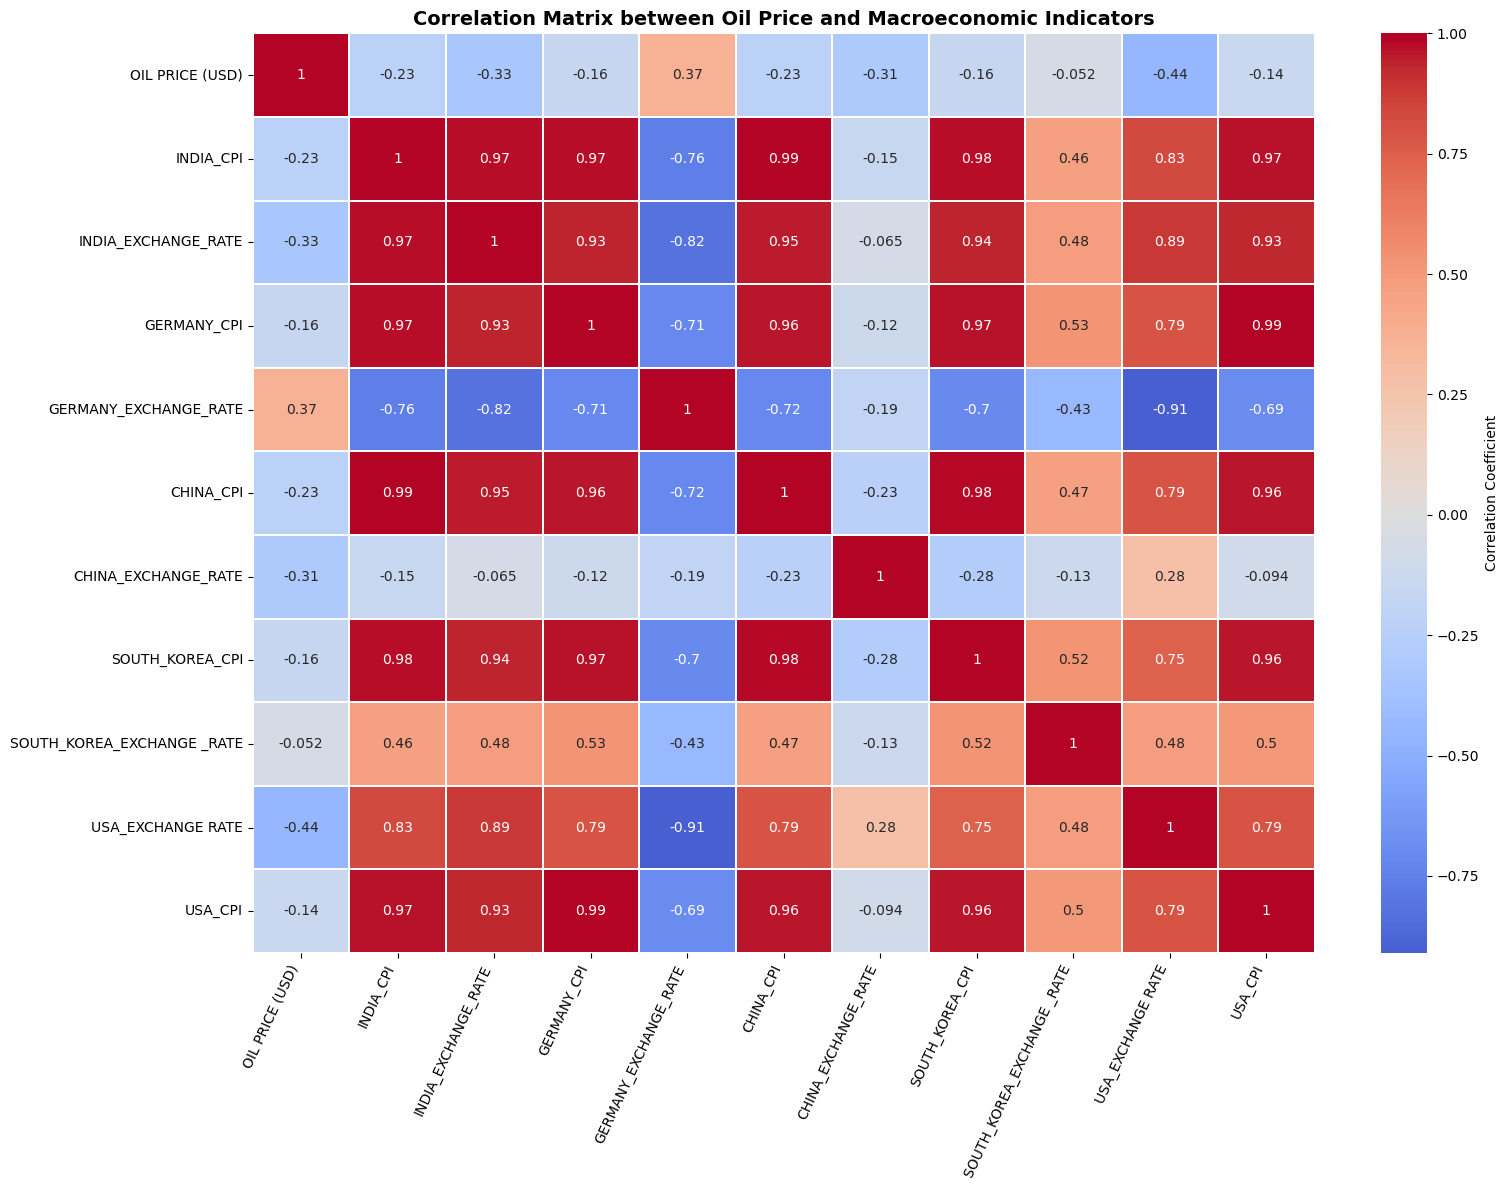

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title("Correlation Matrix between Oil Price and Macroeconomic Indicators",
          fontsize=14, weight='bold')
plt.xticks(rotation=65, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Check for Outliers (Basic Boxplots)

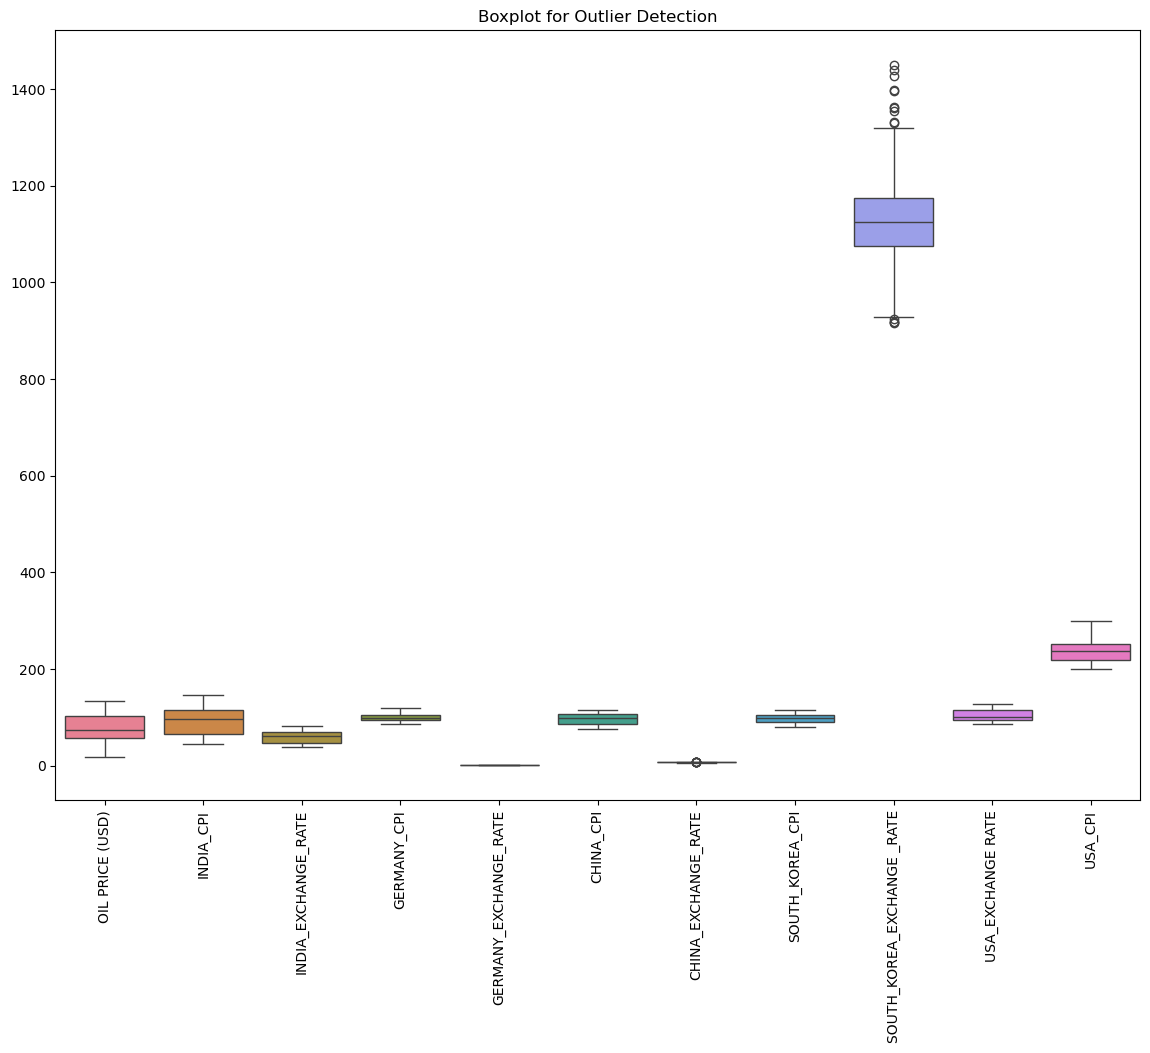

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.boxplot(data=oil_data.drop(columns=['MONTH'], errors='ignore'))
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()


## Check Feature Distributions (Histogram / KDE)

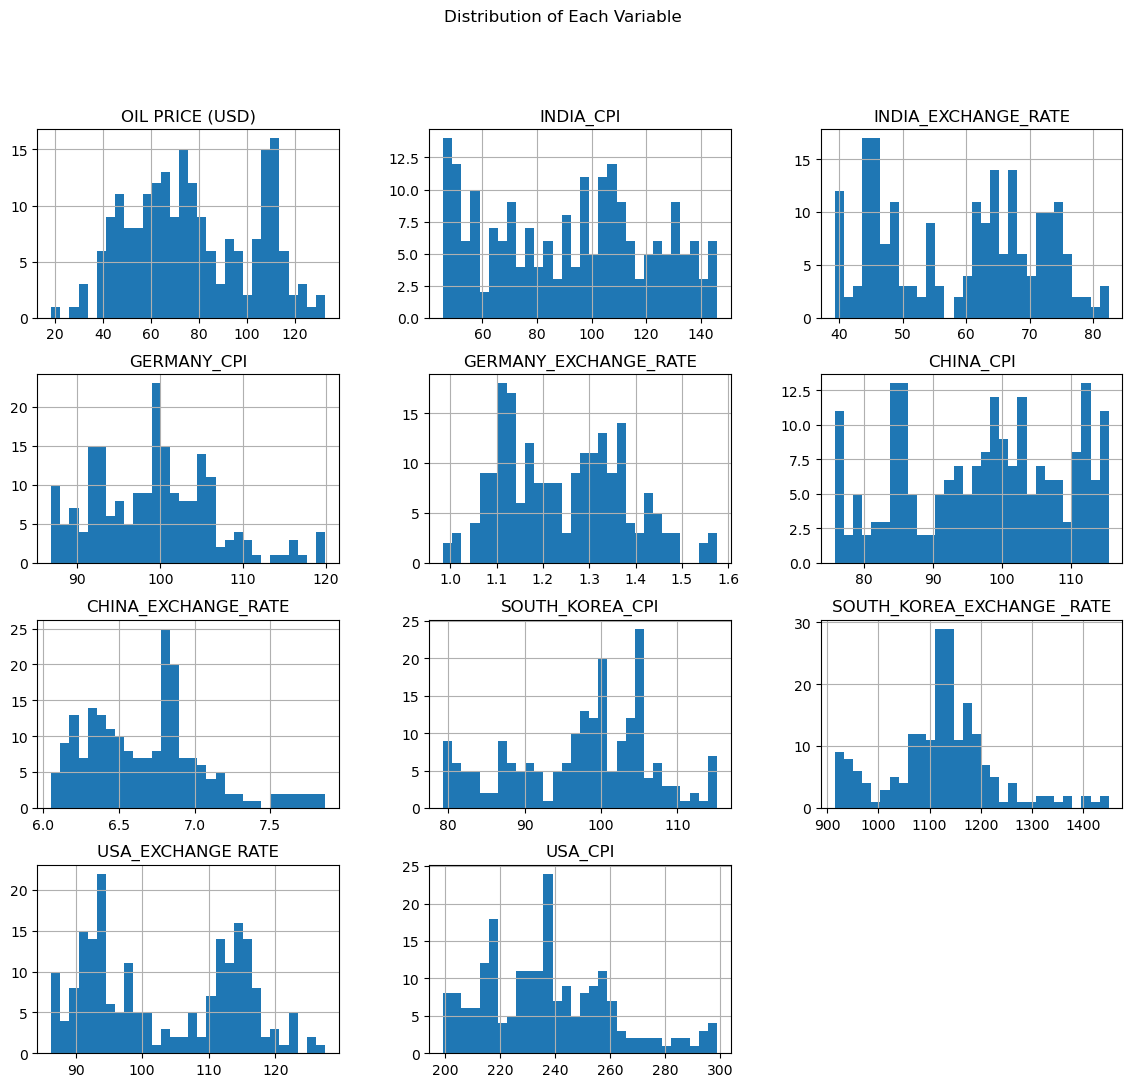

In [9]:
oil_data.hist(figsize=(14,12), bins=30)
plt.suptitle("Distribution of Each Variable")
plt.show()


## Trend Plots (Oil Price vs indicators)

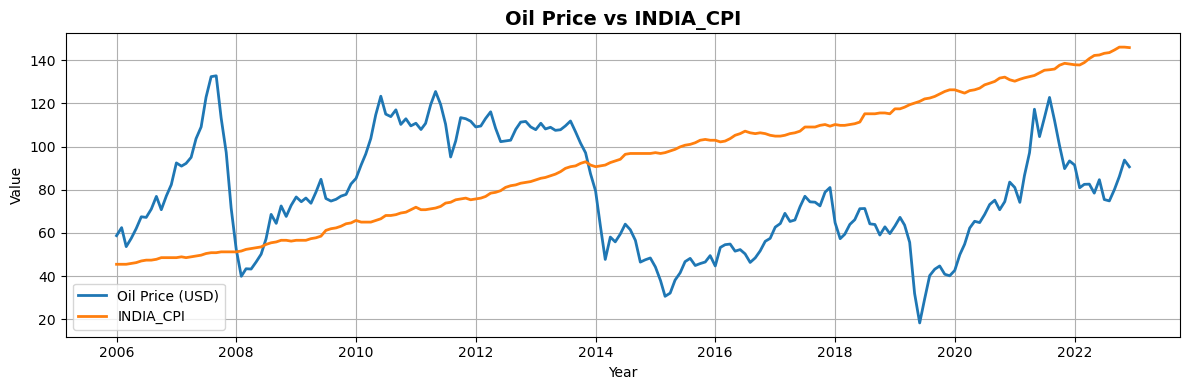

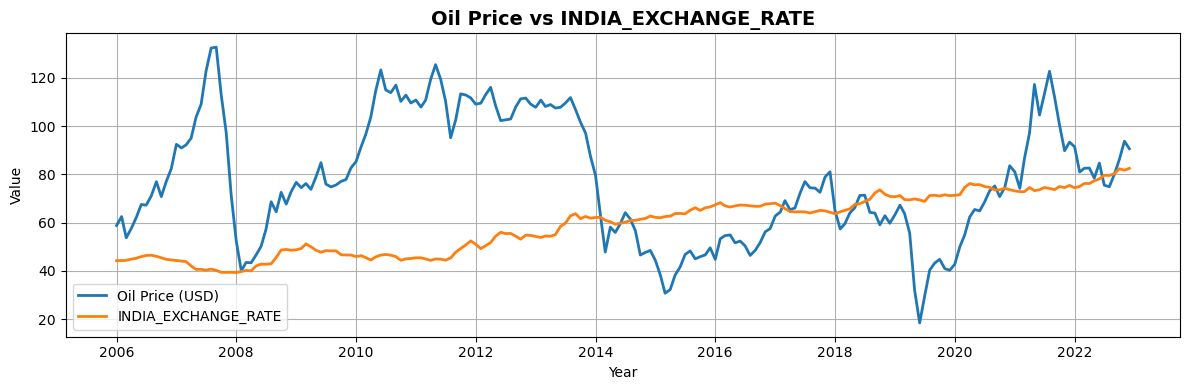

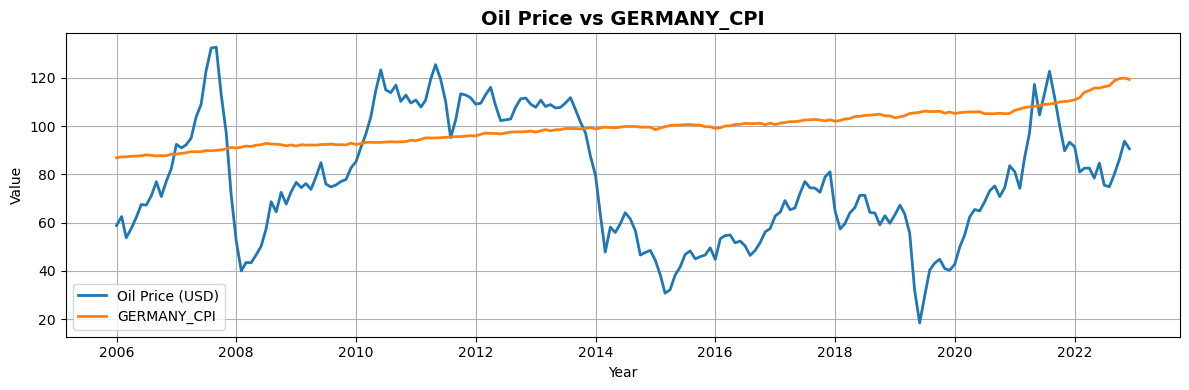

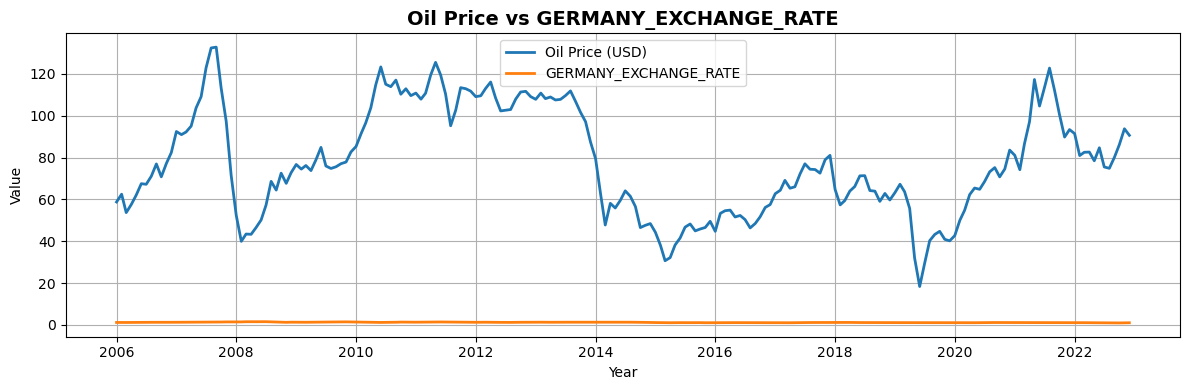

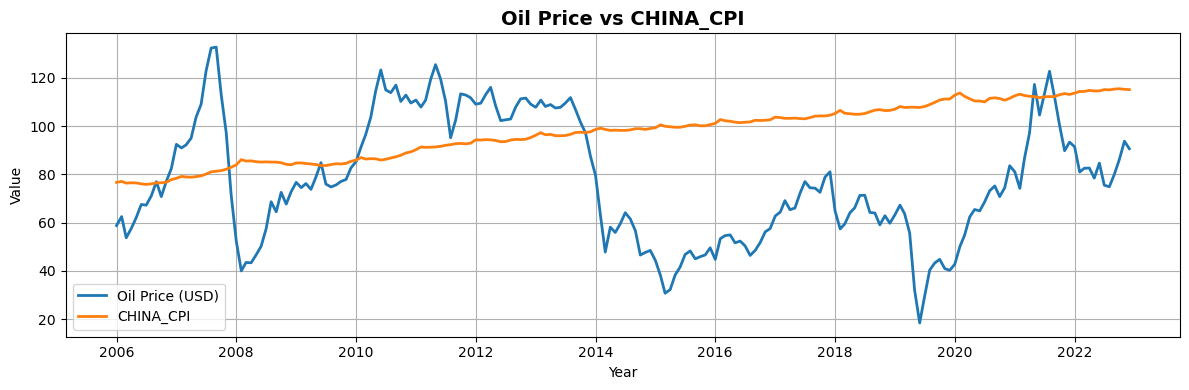

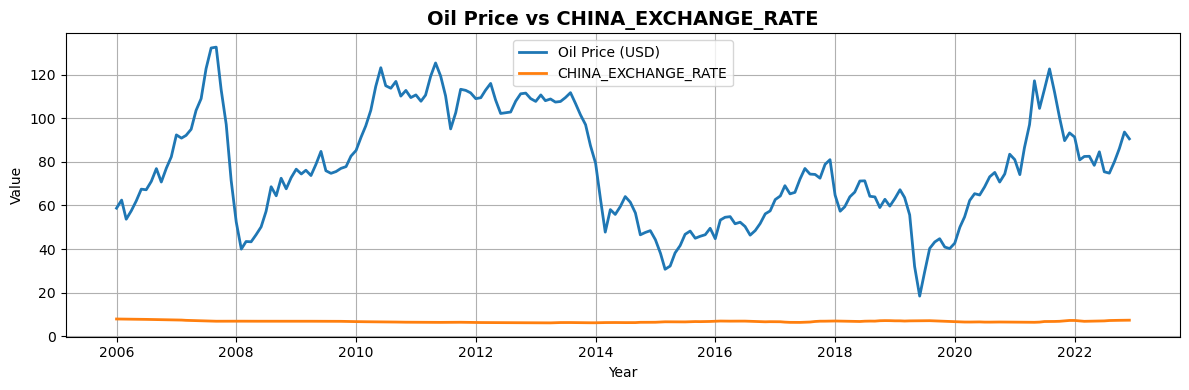

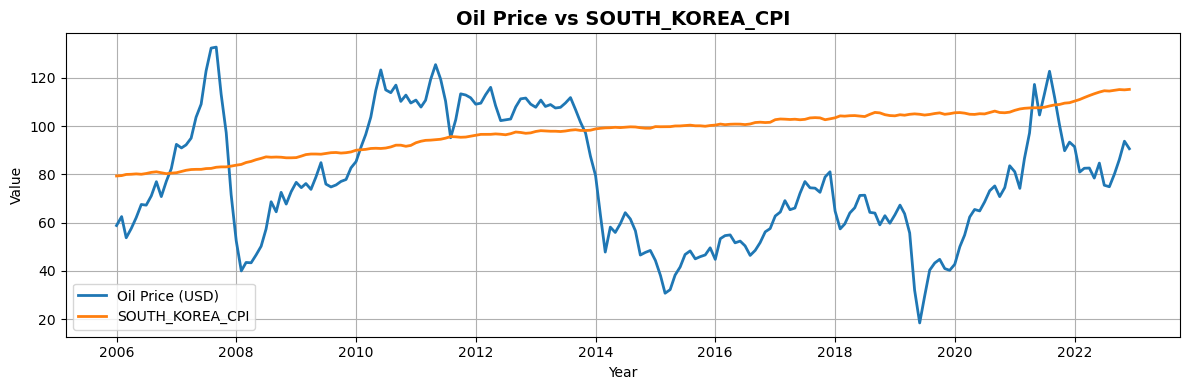

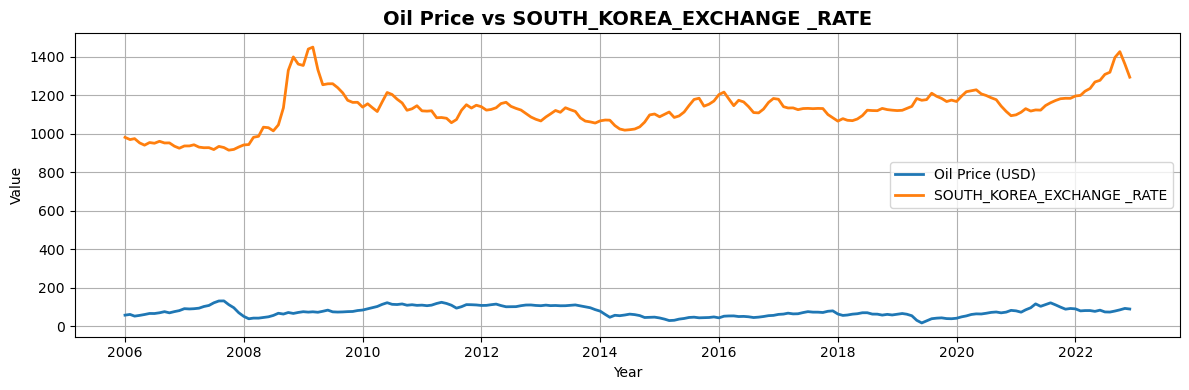

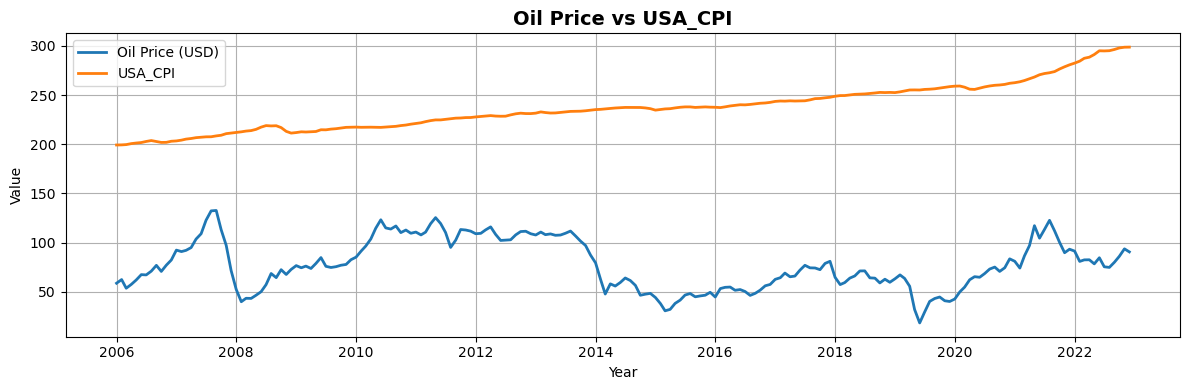

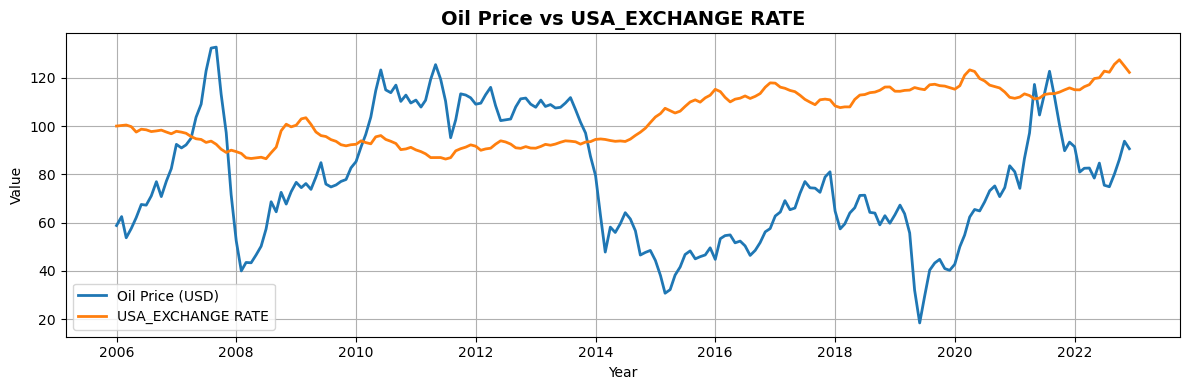

In [10]:
import matplotlib.pyplot as plt

# List of variables to compare with oil price
variables = [
    'INDIA_CPI', 'INDIA_EXCHANGE_RATE',
    'GERMANY_CPI', 'GERMANY_EXCHANGE_RATE',
    'CHINA_CPI', 'CHINA_EXCHANGE_RATE',
    'SOUTH_KOREA_CPI', 'SOUTH_KOREA_EXCHANGE _RATE',
    'USA_CPI', 'USA_EXCHANGE RATE'
]

# Loop through each variable to create a separate plot
for var in variables:
    plt.figure(figsize=(12, 4))
    
    plt.plot(oil_data.index, oil_data['OIL PRICE (USD)'], label='Oil Price (USD)', linewidth=2)
    plt.plot(oil_data.index, oil_data[var], label=var, linewidth=2)
    
    plt.title(f"Oil Price vs {var}", fontsize=14, weight='bold')
    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Z-Score Comparison Plot

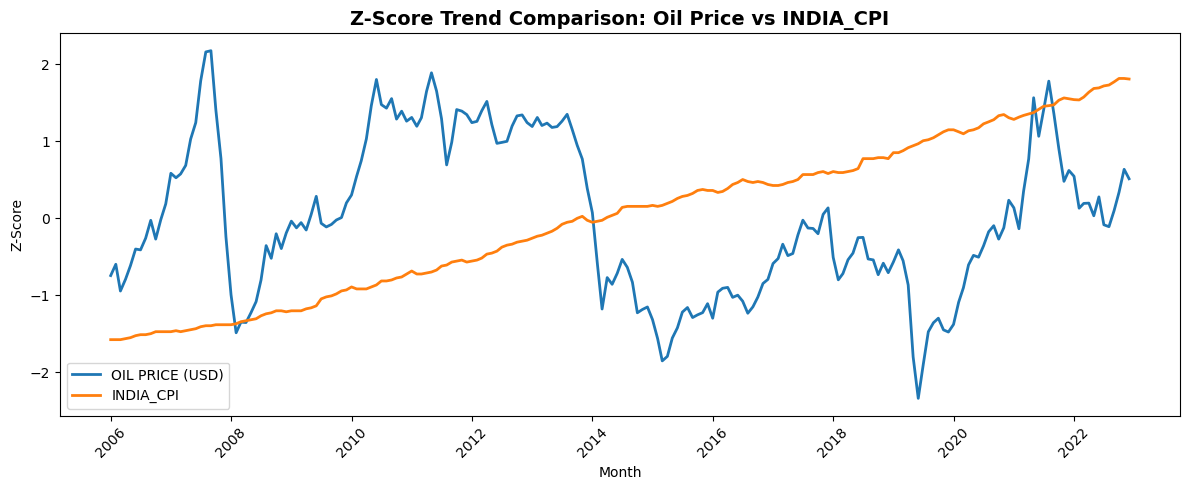

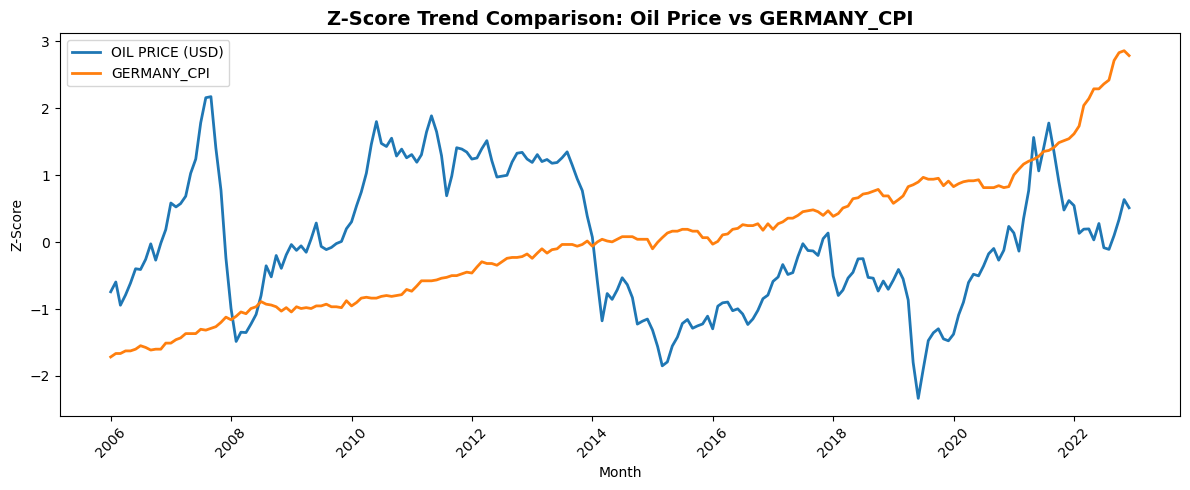

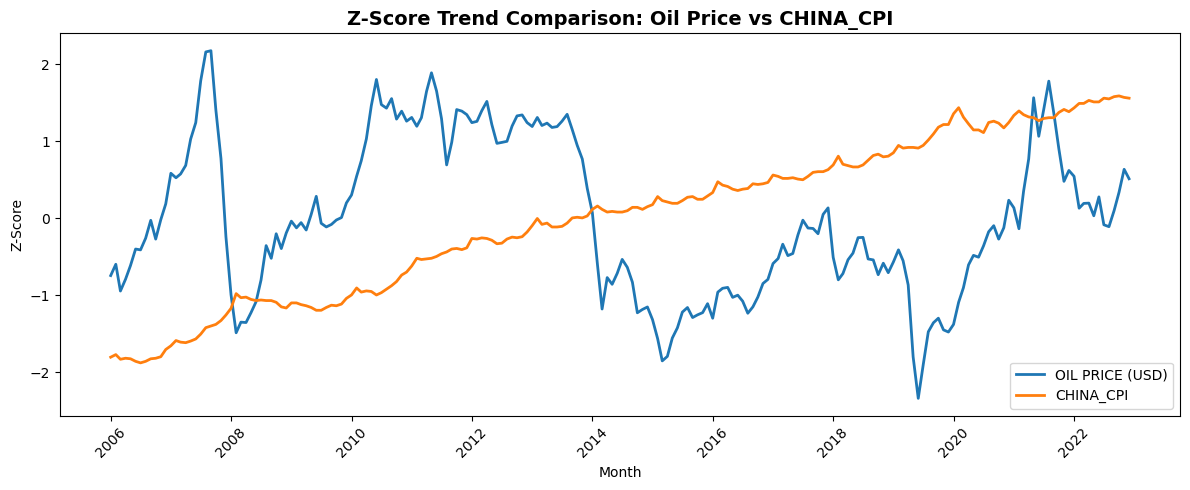

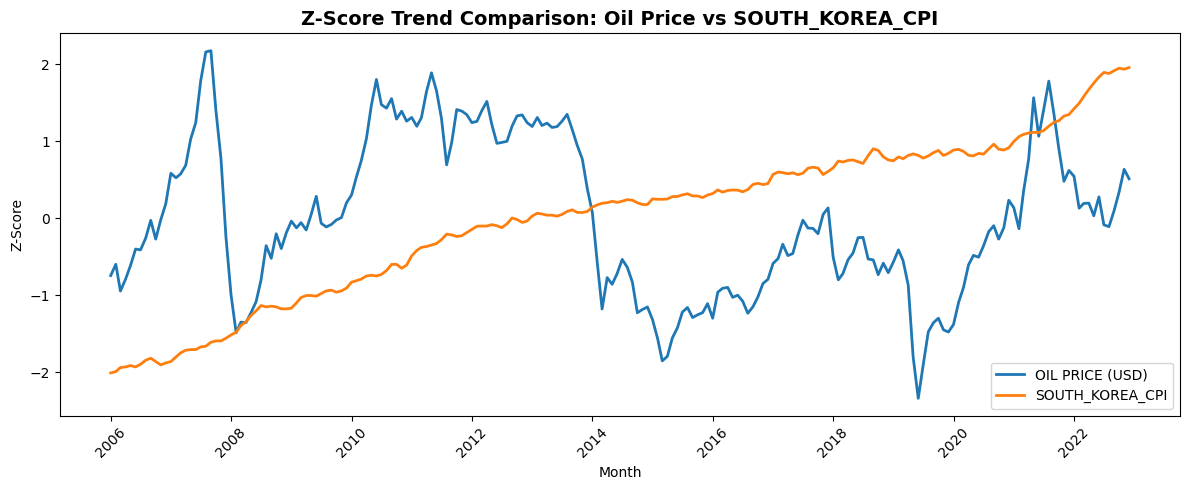

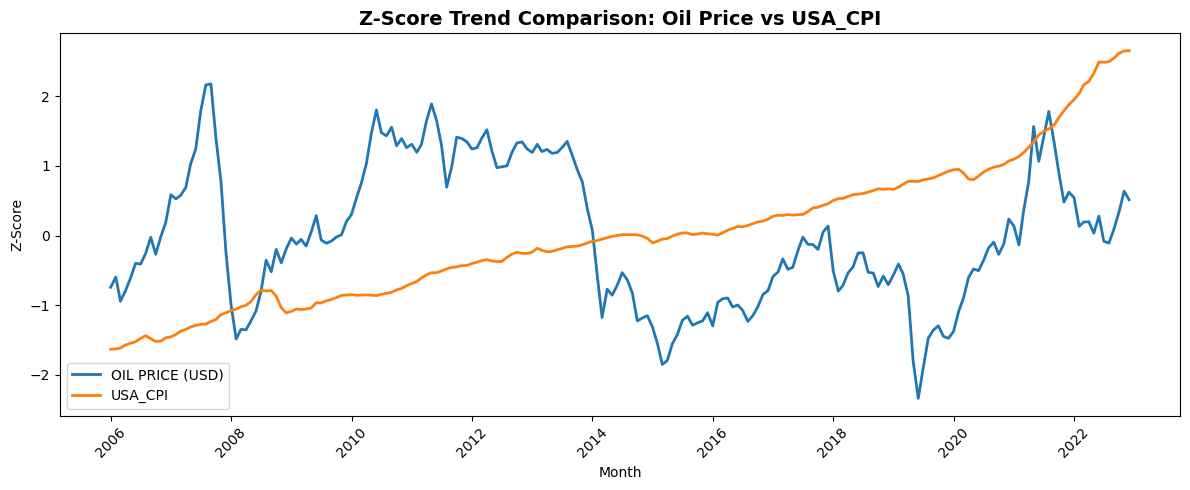

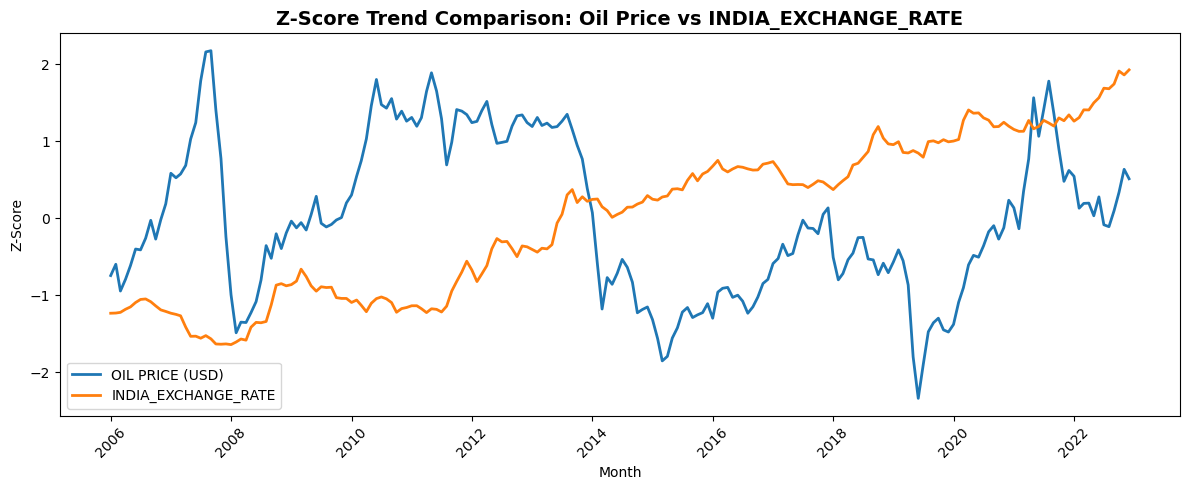

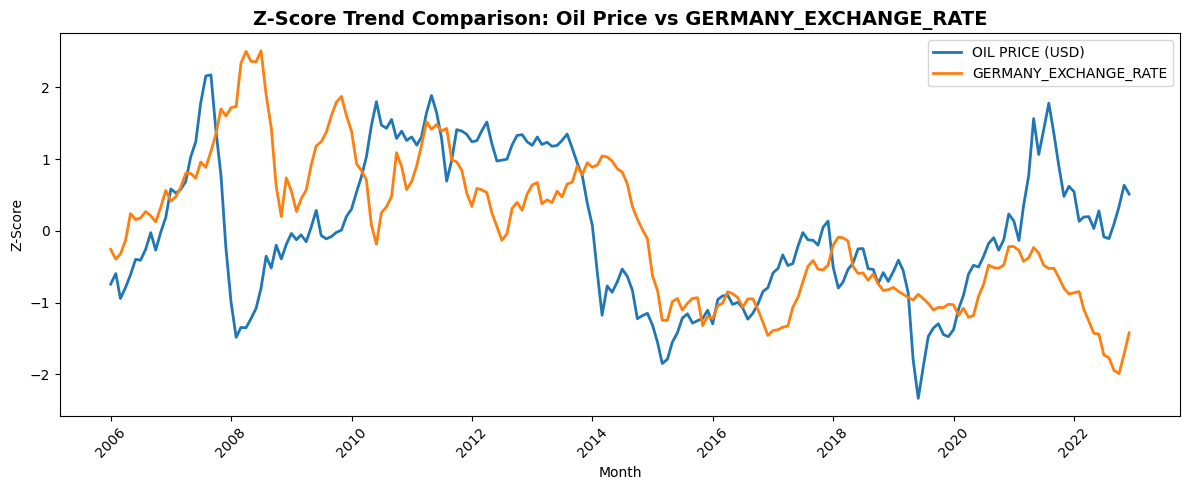

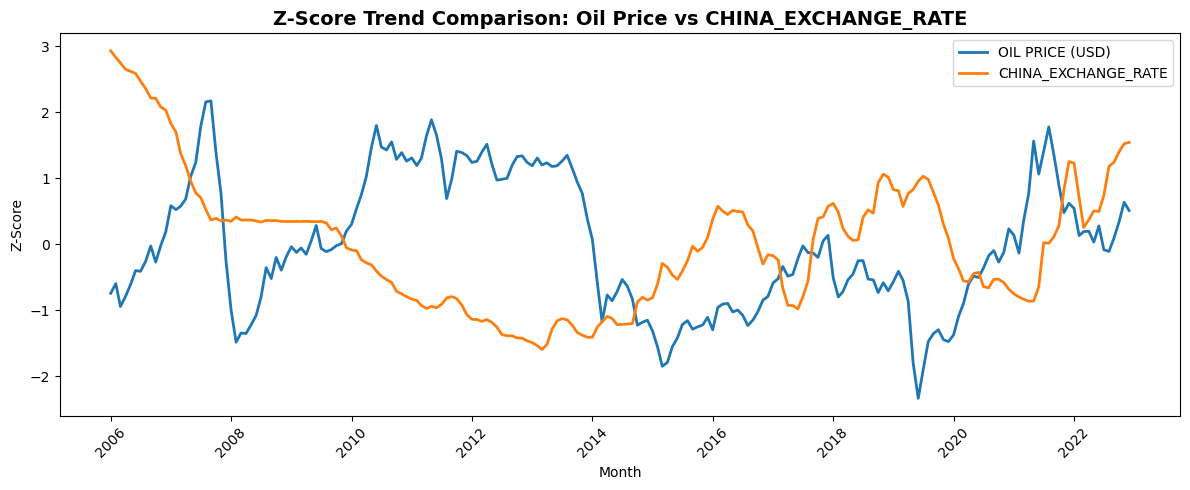

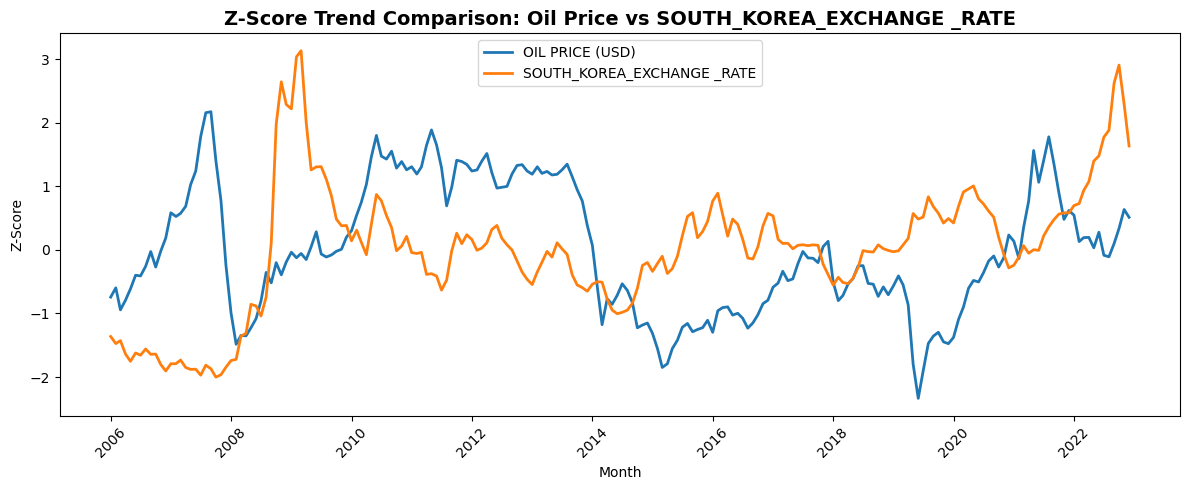

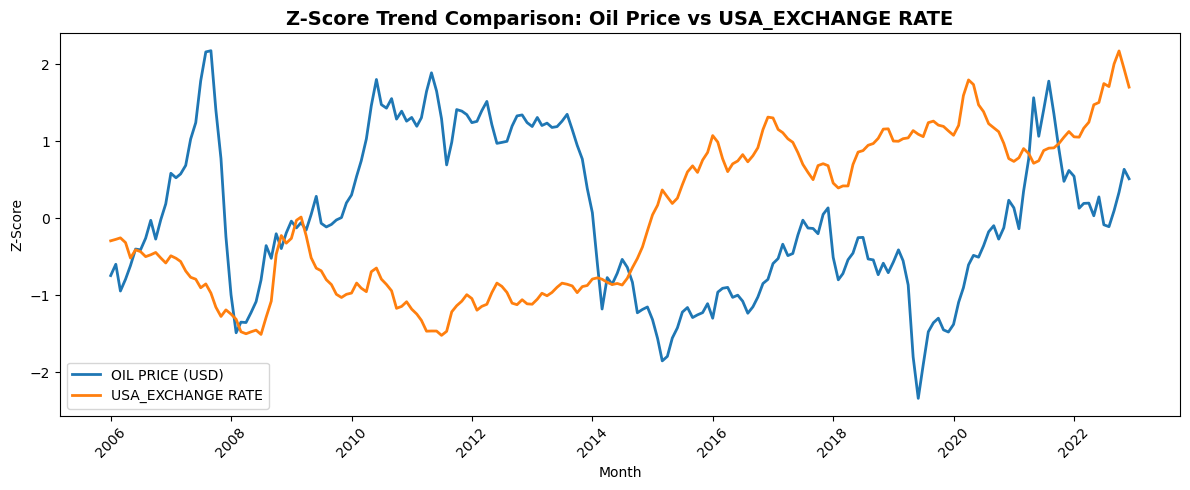

In [11]:
# Normalize selected columns
cols_to_compare = [
    "OIL PRICE (USD)",
    "INDIA_CPI", "GERMANY_CPI", "CHINA_CPI", "SOUTH_KOREA_CPI", "USA_CPI",
    "INDIA_EXCHANGE_RATE", "GERMANY_EXCHANGE_RATE", 
    "CHINA_EXCHANGE_RATE", "SOUTH_KOREA_EXCHANGE _RATE", 
    "USA_EXCHANGE RATE"
]

oil_data_z = (oil_data[cols_to_compare] - oil_data[cols_to_compare].mean()) / oil_data[cols_to_compare].std()

import matplotlib.pyplot as plt

def plot_individual(variable):
    plt.figure(figsize=(12, 5))
    
    # Plot Oil Price
    plt.plot(oil_data_z.index, oil_data_z["OIL PRICE (USD)"],
             label="OIL PRICE (USD)", linewidth=2)
    
    # Plot selected variable
    plt.plot(oil_data_z.index, oil_data_z[variable],
             label=variable, linewidth=2)
    
    plt.title(f"Z-Score Trend Comparison: Oil Price vs {variable}",
              fontsize=14, weight='bold')
    plt.xlabel("Month")
    plt.ylabel("Z-Score")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_individual("INDIA_CPI")
plot_individual("GERMANY_CPI")
plot_individual("CHINA_CPI")
plot_individual("SOUTH_KOREA_CPI")
plot_individual("USA_CPI")
plot_individual("INDIA_EXCHANGE_RATE")
plot_individual("GERMANY_EXCHANGE_RATE")
plot_individual("CHINA_EXCHANGE_RATE")
plot_individual("SOUTH_KOREA_EXCHANGE _RATE")
plot_individual("USA_EXCHANGE RATE")


## Check stationarity of oil price (ADF test)

In [12]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(oil_data['OIL PRICE (USD)'])

print(f"ADF Statistic         = {result[0]:.4f}")
print(f"p-value               = {result[1]:.5f}")
print(f"# Lags used           = {result[2]}")
print(f"# Observations        = {result[3]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}%  = {value:.4f}")


ADF Statistic         = -2.8485
p-value               = 0.05167
# Lags used           = 1
# Observations        = 202
Critical Values:
   1%%  = -3.4631
   5%%  = -2.8760
   10%%  = -2.5745


## Train–Test Split

In [13]:
# Assume oil_data is already cleaned and indexed by Date/Month

# Define target and features
X = oil_data.drop("OIL PRICE (USD)", axis=1)
y = oil_data["OIL PRICE (USD)"]

# Time-based split
train_size = int(len(oil_data) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (163, 10)
Test shape: (41, 10)


## Autocorrelation of Oil Price

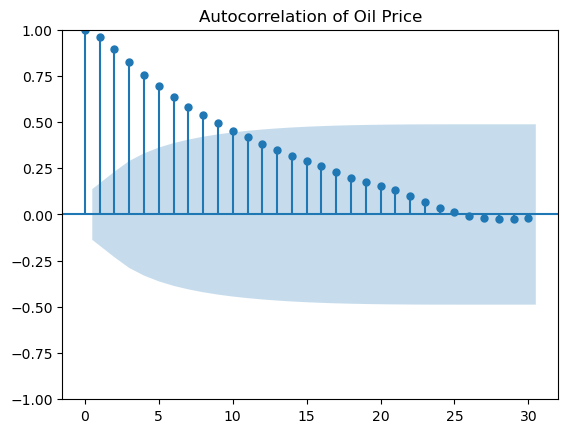

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(oil_data['OIL PRICE (USD)'], lags=30)
plt.title("Autocorrelation of Oil Price")
plt.show()


## Check Feature Importance Before Modeling

In [15]:
from sklearn.ensemble import RandomForestRegressor

temp_rf = RandomForestRegressor(random_state=42)
temp_rf.fit(X_train, y_train)

importances = temp_rf.feature_importances_

for feat, imp in sorted(zip(X.columns, importances), key=lambda x: x[1], reverse=True):
    print(f"{feat}: {imp:.4f}")


SOUTH_KOREA_CPI: 0.3133
USA_EXCHANGE RATE: 0.1569
USA_CPI: 0.0989
GERMANY_EXCHANGE_RATE: 0.0834
SOUTH_KOREA_EXCHANGE _RATE: 0.0827
GERMANY_CPI: 0.0761
CHINA_CPI: 0.0700
CHINA_EXCHANGE_RATE: 0.0590
INDIA_EXCHANGE_RATE: 0.0309
INDIA_CPI: 0.0288


## Modelling

## SARIMAX pipeline (time-series model that can include exogenous macro variables like CPI & exchange rates).

### optionally runs auto_arima if pmdarima is installed (fast model selection),

### otherwise performs a small grid search over a few (p,d,q) and seasonal (P,D,Q,m) combos,

### fits SARIMAX with exogenous regressors (if you provide some),

### evaluates on test set (RMSE/MAE/R²),

### prints diagnostics and saves the model.

In [ ]:
!pip install --upgrade pip
!pip install pmdarima


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 2.7 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 2.2 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.1 MB/s eta 0:00:00


ERROR: To modify pip, please run the following command:
C:\Users\safiy\anaconda3\python.exe -m pip install --upgrade pip


In [ ]:
import pmdarima as pm
print("pmdarima installed successfully!")



In [ ]:
# === SARIMAX pipeline ===
# Requirements: pip install statsmodels pmdarima (pmdarima optional but helpful)
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# 0. Basic checks
target_col = "OIL PRICE (USD)"
if target_col not in oil_data.columns:
    raise ValueError(f"{target_col} not found in oil_data")

# Ensure datetime index sorted
oil_data = oil_data.sort_index()
if not isinstance(oil_data.index, pd.DatetimeIndex):
    oil_data.index = pd.to_datetime(oil_data.index)

# Optional: select exogenous variables (provide list or leave empty)
# Example: exog_cols = ['INDIA_CPI','USA_EXCHANGE RATE','CHINA_EXCHANGE_RATE']
exog_cols = [c for c in oil_data.columns if c != target_col]  # default: all others
# If you don't want to use exog, set exog_cols = []
# exog_cols = []

# 1. Train/test split (time-based)
train_size = int(len(oil_data) * 0.8)
train = oil_data.iloc[:train_size]
test  = oil_data.iloc[train_size:]

y_train = train[target_col]
y_test  = test[target_col]

if len(exog_cols) > 0:
    exog_train = train[exog_cols].astype(float)
    exog_test  = test[exog_cols].astype(float)
else:
    exog_train = None
    exog_test  = None

print("SARIMAX: train rows:", len(y_train), "test rows:", len(y_test))
print("Using exogenous columns:", exog_cols if exog_cols else "None")

# 2. Model selection: try auto_arima if available, else small grid search
use_auto = False
try:
    import pmdarima as pm
    use_auto = True
except Exception:
    use_auto = False

if use_auto:
    print("pmdarima found → running auto_arima (this may take a bit)...")
    auto = pm.auto_arima(
        y_train,
        exogenous=exog_train,
        seasonal=True,
        m=12,                  # monthly seasonality
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        max_p=3, max_q=3, max_P=2, max_Q=2, max_d=2, max_D=1
    )
    order = auto.order
    seasonal_order = auto.seasonal_order
    print("auto_arima selected order:", order, "seasonal_order:", seasonal_order)
else:
    # small manual grid (keeps runtime reasonable)
    print("pmdarima not installed -> using small manual grid search")
    best_aic = np.inf
    best_cfg = None
    # small ranges
    p_vals = [0,1,2]
    d_vals = [0,1]
    q_vals = [0,1,2]
    P_vals = [0,1]
    D_vals = [0,1]
    Q_vals = [0,1]
    m = 12
    for p in p_vals:
        for d in d_vals:
            for q in q_vals:
                for P in P_vals:
                    for D in D_vals:
                        for Q in Q_vals:
                            try:
                                order = (p,d,q)
                                seasonal_order = (P,D,Q,m)
                                mod = SARIMAX(y_train, exog=exog_train, order=order, seasonal_order=seasonal_order,
                                              enforce_stationarity=False, enforce_invertibility=False)
                                res = mod.fit(disp=False, maxiter=200)
                                if res.aic < best_aic:
                                    best_aic = res.aic
                                    best_cfg = (order, seasonal_order)
                            except Exception:
                                continue
    if best_cfg is None:
        raise RuntimeError("Grid search failed to fit any SARIMAX model.")
    order, seasonal_order = best_cfg
    print("Grid search selected order:", order, "seasonal_order:", seasonal_order, "best AIC:", best_aic)

# 3. Fit final SARIMAX
print("Fitting final SARIMAX model...")
model = SARIMAX(y_train, exog=exog_train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False, maxiter=500)
print(res.summary().tables[1])

# 4. Diagnostics (residuals)
residuals = res.resid
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("SARIMAX residuals (train)")
plt.tight_layout()
plt.show()

# 5. Forecast on test set / evaluate
if exog_test is not None:
    pred_res = res.get_forecast(steps=len(y_test), exog=exog_test)
    y_pred = pred_res.predicted_mean
else:
    pred_res = res.get_forecast(steps=len(y_test))
    y_pred = pred_res.predicted_mean

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print("\nSARIMAX Performance on test set")
print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

# 6. Plot actual vs predicted
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='SARIMAX Predicted', linestyle='--')
plt.legend()
plt.title('SARIMAX: Actual vs Predicted (Test)')
plt.tight_layout()
plt.show()

# 7. Save model
joblib.dump(res, "sarimax_model.pkl")
print("Saved SARIMAX results to 'sarimax_model.pkl'")


## Random Forest with lag features (ML comparison)

### builds lag (1,3,6,12) and rolling features,

### does time-based train/test (80/20),

### trains RandomForestRegressor,

### evaluates on test set, prints numeric table,

### compares with persistence baseline (lag_1),

 ### prints feature importances (Gini + permutation),

### saves model and results.

In [ ]:
# === Random Forest with lag features pipeline ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings("ignore")

# 0. Basic checks & prepare index
target_col = "OIL PRICE (USD)"

# Ensure index is date and sorted
oil_data.index = pd.to_datetime(oil_data.index)
oil_data = oil_data.sort_index()


# 1. Create lags and rolling features
lags = [1,3,6,12]
for lag in lags:
    oil_data[f"lag_{lag}"] = oil_data[target_col].shift(lag)

oil_data['roll_mean_3']  = oil_data[target_col].rolling(3, min_periods=1).mean().shift(1)
oil_data['roll_mean_6']  = oil_data[target_col].rolling(6, min_periods=1).mean().shift(1)
oil_data['roll_mean_12'] = oil_data[target_col].rolling(12, min_periods=1).mean().shift(1)
oil_data['roll_std_3']   = oil_data[target_col].rolling(3, min_periods=1).std().shift(1).fillna(0)

# Calendar features
oil_data['month'] = oil_data.index.month
oil_data['month_sin'] = np.sin(2*np.pi*oil_data['month']/12)
oil_data['month_cos'] = np.cos(2*np.pi*oil_data['month']/12)

# 2. Drop rows with NaNs due to shifts
df = oil_data.dropna(subset=[f"lag_{max(lags)}"]).copy()

# 3. Feature matrix X and target y
# Exogenous macro columns will be used automatically if present — they remain in df.
X = df.drop(columns=[target_col])
# Keep numeric features only
X = X.select_dtypes(include=[np.number])
y = df[target_col]

# 5. Persistence baseline (lag_1)
if 'lag_1' in X_test.columns:
    y_pred_persist = X_test['lag_1'].values
    persist_rmse = np.sqrt(mean_squared_error(y_test, y_pred_persist))
    persist_mae  = mean_absolute_error(y_test, y_pred_persist)
    print(f"Persistence baseline (lag_1) -> RMSE: {persist_rmse:.4f}, MAE: {persist_mae:.4f}")
else:
    print("No lag_1 found for persistence baseline.")

# 6. Train baseline RandomForest
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest trained.")

# 7. Evaluate on test set
y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print("\nRandom Forest (Test) -> RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}".format(rmse, mae, r2))

# Numeric results table
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Residual': y_test.values - y_pred,
    'Pred_prev_month': X_test['lag_1'].values if 'lag_1' in X_test.columns else np.nan
}, index=y_test.index)
print("\nFirst 10 rows of predictions:")
print(results.head(10))
print("\nResiduals summary:")
print(results['Residual'].describe())

results.to_csv("rf_results_with_lags.csv")
print("Saved rf_results_with_lags.csv")

# 8. Feature importances (impurity + permutation)
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop features by impurity importance:")
print(imp.head(15))

perm = permutation_importance(rf, X_test, y_test, n_repeats=25, random_state=42, n_jobs=-1)
perm_ser = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)
print("\nTop features by permutation importance:")
print(perm_ser.head(15))

# 9. Plots
plt.figure(figsize=(10,4))
plt.plot(results.index, results['Actual'], label='Actual')
plt.plot(results.index, results['Predicted'], label='RF Predicted', linestyle='--')
plt.legend()
plt.title('Random Forest: Actual vs Predicted (Test)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(results['Actual'], results['Predicted'], alpha=0.6)
minv, maxv = min(results['Actual'].min(), results['Predicted'].min()), max(results['Actual'].max(), results['Predicted'].max())
plt.plot([minv, maxv], [minv, maxv], '--', color='black')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('RF Predicted vs Actual (Test)')
plt.tight_layout()
plt.show()

# 10. Save model
joblib.dump(rf, "rf_with_lags.joblib")
print("Saved RF model to 'rf_with_lags.joblib'")


## XGBoost (Gradient Boosting) model

In [ ]:
pip install xgboost


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# ===============================
# 0. Basic setup
# ===============================
target_col = "OIL PRICE (USD)"

# If MONTH is already the index, this is enough:
oil_data.index = pd.to_datetime(oil_data.index)
oil_data = oil_data.sort_index()

if target_col not in oil_data.columns:
    raise ValueError(f"{target_col} not found in oil_data.columns")

# ===============================
# 1. Create lag and rolling features (same as RF)
#    (Skip this part if you've ALREADY created them earlier)
# ===============================
lags = [1, 3, 6, 12]
for lag in lags:
    oil_data[f"lag_{lag}"] = oil_data[target_col].shift(lag)

oil_data["roll_mean_3"]  = oil_data[target_col].rolling(3,  min_periods=1).mean().shift(1)
oil_data["roll_mean_6"]  = oil_data[target_col].rolling(6,  min_periods=1).mean().shift(1)
oil_data["roll_mean_12"] = oil_data[target_col].rolling(12, min_periods=1).mean().shift(1)
oil_data["roll_std_3"]   = oil_data[target_col].rolling(3,  min_periods=1).std().shift(1).fillna(0)

# Calendar / seasonality
oil_data["month"]     = oil_data.index.month
oil_data["month_sin"] = np.sin(2 * np.pi * oil_data["month"] / 12)
oil_data["month_cos"] = np.cos(2 * np.pi * oil_data["month"] / 12)

# ===============================
# 2. Drop rows with missing lags
# ===============================
df = oil_data.dropna(subset=[f"lag_{max(lags)}"]).copy()

# ===============================
# 3. Build X and y
# ===============================
X = df.drop(columns=[target_col])
X = X.select_dtypes(include=[np.number])   # numeric only
y = df[target_col]

# ===============================
# 4. Time-based train/test split
# ===============================
train_size = int(len(df) * 0.8)
X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print("XGBoost: Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ===============================
# 5. Persistence baseline (lag_1)
# ===============================
if "lag_1" in X_test.columns:
    y_pred_persist = X_test["lag_1"].values
    persist_rmse = np.sqrt(mean_squared_error(y_test, y_pred_persist))
    persist_mae  = mean_absolute_error(y_test, y_pred_persist)
    print(f"Persistence baseline (lag_1) -> RMSE: {persist_rmse:.4f}, MAE: {persist_mae:.4f}")
else:
    print("No lag_1 column found for persistence baseline.")

# ===============================
# 6. Train XGBoost Regressor
# ===============================
xgb = XGBRegressor(
    n_estimators=500,        # number of trees
    learning_rate=0.03,      # smaller = smoother
    max_depth=3,             # tree depth
    subsample=0.8,           # row sampling
    colsample_bytree=0.8,    # feature sampling
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
print("XGBoost model trained.")

# ===============================
# 7. Evaluate on test set
# ===============================
y_pred = xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\nXGBoost (Test) -> RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}".format(rmse, mae, r2))

# Combine in a results DataFrame
results_xgb = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": y_test.values - y_pred,
    "Pred_prev_month": X_test["lag_1"].values if "lag_1" in X_test.columns else np.nan
}, index=y_test.index)

print("\nFirst 10 rows of XGBoost predictions:")
print(results_xgb.head(10))

print("\nResiduals summary (XGBoost):")
print(results_xgb["Residual"].describe())

results_xgb.to_csv("xgb_results_with_lags.csv")
print("Saved xgb_results_with_lags.csv")

# ===============================
# 8. Feature importance (gain-based)
# ===============================
importances = xgb.feature_importances_
imp_ser = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

print("\nTop features by XGBoost importance:")
print(imp_ser.head(15))

# ===============================
# 9. Plots: Actual vs Predicted
# ===============================
plt.figure(figsize=(10,4))
plt.plot(results_xgb.index, results_xgb["Actual"], label="Actual")
plt.plot(results_xgb.index, results_xgb["Predicted"], label="XGBoost Predicted", linestyle="--")
plt.legend()
plt.title("XGBoost: Actual vs Predicted (Test)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(results_xgb["Actual"], results_xgb["Predicted"], alpha=0.6)
minv = min(results_xgb["Actual"].min(), results_xgb["Predicted"].min())
maxv = max(results_xgb["Actual"].max(), results_xgb["Predicted"].max())
plt.plot([minv, maxv], [minv, maxv], "--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Predicted vs Actual (Test)")
plt.tight_layout()
plt.show()


In [ ]:
## Time-Series Cross-Validation (5-Fold)

In [ ]:
# ===============================
# TIME-SERIES CROSS-VALIDATION
# ===============================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the same df with lag features already created
# Make sure X and y are defined from earlier in your notebook

tscv = TimeSeriesSplit(n_splits=5)

# ---- XGBoost CV ----
xgb_cv_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    
    xgb_cv_scores.append({'Fold': fold+1, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    print(f"Fold {fold+1} → RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

xgb_cv_df = pd.DataFrame(xgb_cv_scores)
print("\n--- XGBoost CV Summary ---")
print(xgb_cv_df)
print(f"\nMean RMSE : {xgb_cv_df['RMSE'].mean():.4f} ± {xgb_cv_df['RMSE'].std():.4f}")
print(f"Mean MAE  : {xgb_cv_df['MAE'].mean():.4f} ± {xgb_cv_df['MAE'].std():.4f}")
print(f"Mean R²   : {xgb_cv_df['R2'].mean():.4f} ± {xgb_cv_df['R2'].std():.4f}")

# ---- Random Forest CV ----
rf_cv_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    
    model = RandomForestRegressor(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    
    rf_cv_scores.append({'Fold': fold+1, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

rf_cv_df = pd.DataFrame(rf_cv_scores)
print("\n--- Random Forest CV Summary ---")
print(rf_cv_df)
print(f"\nMean RMSE : {rf_cv_df['RMSE'].mean():.4f} ± {rf_cv_df['RMSE'].std():.4f}")
print(f"Mean MAE  : {rf_cv_df['MAE'].mean():.4f} ± {rf_cv_df['MAE'].std():.4f}")
print(f"Mean R²   : {rf_cv_df['R2'].mean():.4f} ± {rf_cv_df['R2'].std():.4f}")

# ---- Comparison Plot ----
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xgb_cv_df['Fold'], xgb_cv_df['RMSE'], marker='o', label='XGBoost')
ax.plot(rf_cv_df['Fold'],  rf_cv_df['RMSE'],  marker='s', label='Random Forest')
ax.set_xlabel('Fold')
ax.set_ylabel('RMSE')
ax.set_title('Time-Series Cross-Validation: RMSE per Fold')
ax.legend()
plt.tight_layout()
plt.show()